# Gradient Boosting — Insurance Claims Severity (Diabetes dataset as proxy)

Regression with baselines, preprocessing, CV, tuning, and partial dependence style interpretation.
Dataset: `sklearn.datasets.load_diabetes` (real).

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Load dataset

Load data into a pandas DataFrame/Series and perform a first sanity check.

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True)
df = data.frame.copy()
df['target'] = data.target
display(df.head())


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

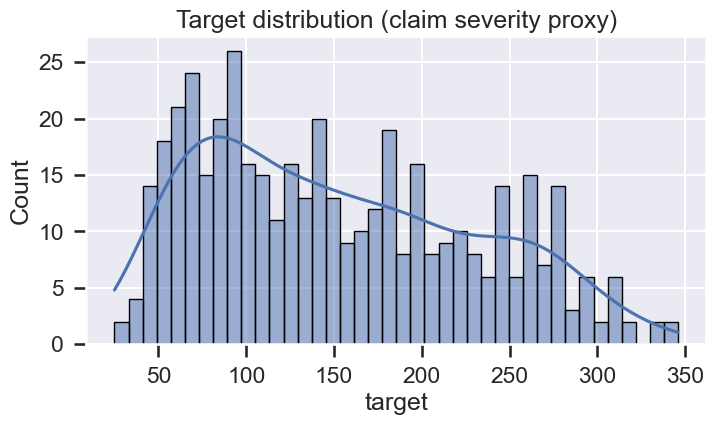

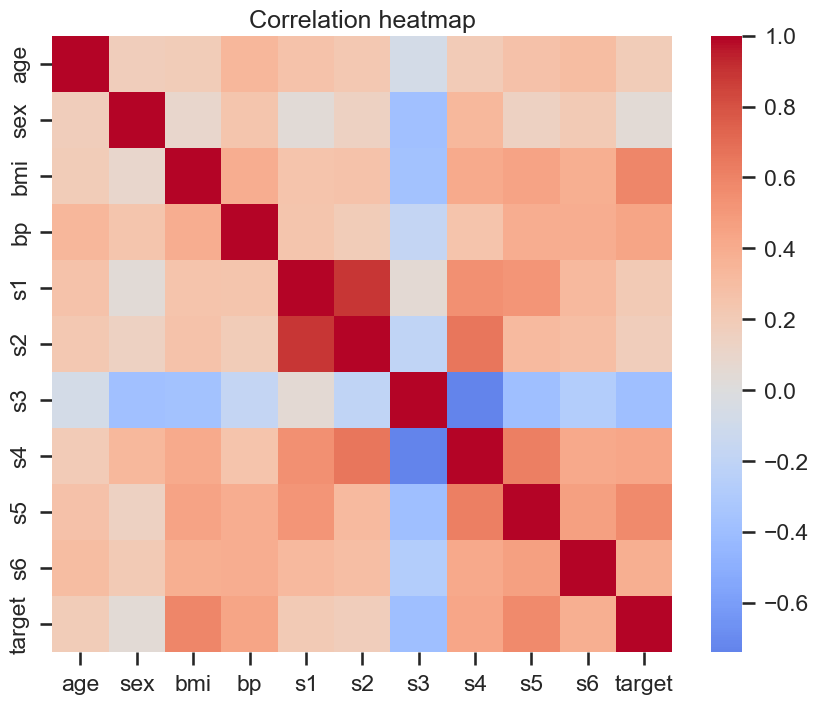

In [3]:
plt.figure(figsize=(8,4))
sns.histplot(df['target'], kde=True, bins=40)
plt.title('Target distribution (claim severity proxy)')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()


## Baselines vs boosting (CV)

In [4]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor

X = df.drop(columns=['target'])
y = df['target']

prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

models = {
    'dummy': DummyRegressor(strategy='mean'),
    'ridge': Ridge(alpha=1.0, random_state=SEED),
    'gbr': GradientBoostingRegressor(random_state=SEED),
    'hgb': HistGradientBoostingRegressor(random_state=SEED),
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

import pandas as pd
rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({'model': name, 'rmse': -res['test_rmse'].mean(), 'r2': res['test_r2'].mean()})

display(pd.DataFrame(rows).sort_values('rmse'))


,model,rmse,r2
1,ridge,54.827054,0.479072
2,gbr,58.319638,0.413445
3,hgb,58.860587,0.402915
0,dummy,77.193405,-0.019355


## Hyperparameter tuning (HistGB)

In [5]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

pipe = Pipeline([('prep', prep), ('model', HistGradientBoostingRegressor(random_state=SEED))])
space = {
    'model__learning_rate': [0.02, 0.05, 0.1],
    'model__max_depth': [None, 3, 5, 8],
    'model__max_leaf_nodes': [15, 31, 63],
    'model__min_samples_leaf': [10, 20, 50, 100],
}
rs = RandomizedSearchCV(pipe, space, n_iter=25, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=SEED)
rs.fit(X, y)
print('Best RMSE (CV):', -rs.best_score_)
print('Best params:', rs.best_params_)


Best RMSE (CV): 55.73418847938002
Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 31, 'model__max_depth': 3, 'model__learning_rate': 0.05}


## Interpretation (permutation importance)

Permutation importance offers a model-agnostic view of influential features.

,feature,importance
8,s5,0.324479
2,bmi,0.267904
3,bp,0.087640
6,s3,0.041354
1,sex,0.039400
0,age,0.029173
9,s6,0.028318
5,s2,0.021122
4,s1,0.009545
7,s4,0.005057


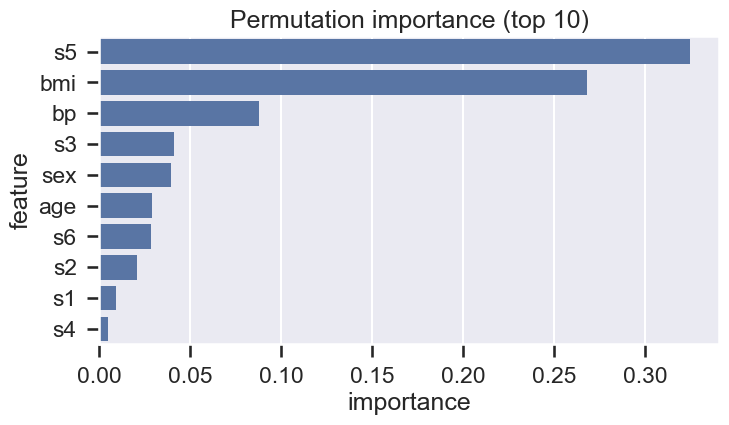

In [6]:
from sklearn.inspection import permutation_importance

best = rs.best_estimator_
best.fit(X, y)

perm = permutation_importance(best, X, y, n_repeats=10, random_state=SEED, n_jobs=-1, scoring='r2')
imp = (
    pd.DataFrame({'feature': X.columns, 'importance': perm.importances_mean})
    .sort_values('importance', ascending=False)
    .head(10)
)
display(imp)

plt.figure(figsize=(8,4))
sns.barplot(data=imp, x='importance', y='feature')
plt.title('Permutation importance (top 10)')
plt.show()
